# Creating the Mask

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class

## Opening H-alpha FITS

In [2]:
# in this case, h-alpha map from muse is being opened with h-alpha disk & irac1 disk 
from astropy.io import fits 
from astropy.wcs import WCS
with fits.open(r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/NGC0253_Ha.fits") as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
if data is None:
    print("None")
            
wcs = WCS(header) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        # access region file via parsing & converting data from wcs to pixel. the 0 is for the FIRST region plotted
        # for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an index exists for that region

        



Found data in extension: HA6562_FLUX


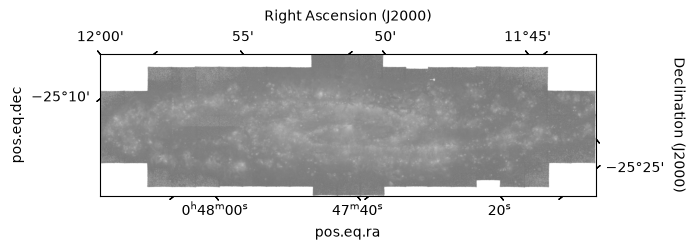

## Disk: Mask

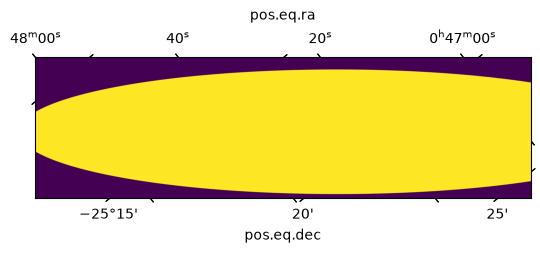

In [30]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
disk_region1 = Regions.read(r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/disk_ha_regionfile_adjusted71026_muse-Copy1")[0].to_pixel(wcs)
mask = disk_region1.to_mask(mode='subpixels') #https://astropy-regions.readthedocs.io/en/stable/user_guide/masks.html#defining-a-region-mask-within-an-image
ax.imshow(mask.to_image(data.shape), cmap='viridis', origin='lower')
plt.savefig('Mask: Disk, H-alpha Map')

## Spiral Arms: Mask

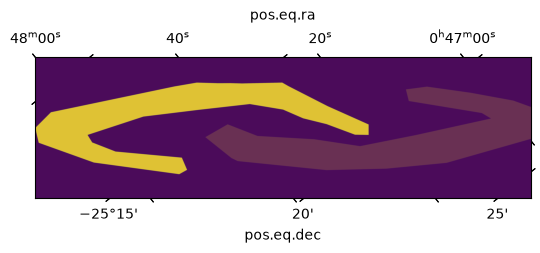

In [32]:
ha_spiralarms_regionfile =  r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/spiralarms_ha_regionfile_muse.reg"
spiralarms_region1 = Regions.read(ha_spiralarms_regionfile)[0].to_pixel(wcs)  
spiralarms_region11 = Regions.read(ha_spiralarms_regionfile)[1].to_pixel(wcs)

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
mask1 = spiralarms_region1.to_mask(mode='subpixels') #https://astropy-regions.readthedocs.io/en/stable/user_guide/masks.html#defining-a-region-mask-within-an-image
mask11 = spiralarms_region11.to_mask(mode='subpixels')
ax.imshow(mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.8)
ax.imshow(mask11.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.8)
plt.savefig('Mask: Spiral Arms, H-alpha Map')

## Center: Mask

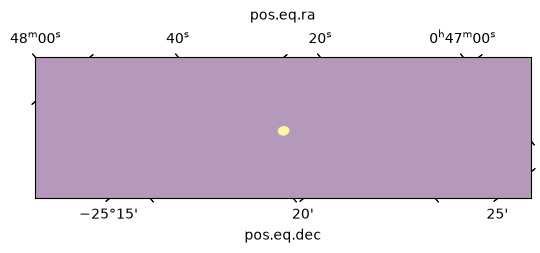

In [33]:
ha_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_ha_regionfile_muse.reg"
center_region1 = Regions.read(ha_center_regionfile)[0].to_pixel(wcs)

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
center_mask1 = center_region1.to_mask(mode='subpixels') #https://astropy-regions.readthedocs.io/en/stable/user_guide/masks.html#defining-a-region-mask-within-an-image
ax.imshow(center_mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4)
plt.savefig('Mask: Center, H-alpha Map')

## Bar: Mask

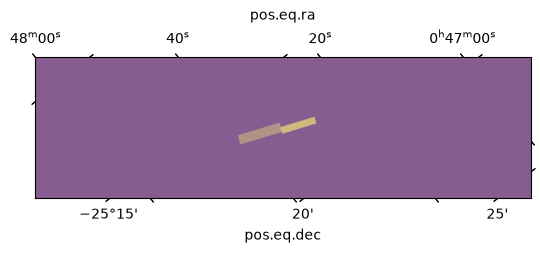

In [34]:
ha_bar_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/bar_ha_regionfile_muse_twoboxes.reg"
bar_region1 = Regions.read(ha_bar_regionfile)[0].to_pixel(wcs)
bar_region11 = Regions.read(ha_bar_regionfile)[1].to_pixel(wcs)

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
bar_mask1 = bar_region1.to_mask(mode='subpixels') #https://astropy-regions.readthedocs.io/en/stable/user_guide/masks.html#defining-a-region-mask-within-an-image
bar_mask11 = bar_region11.to_mask(mode='subpixels')
ax.imshow(bar_mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4)
ax.imshow(bar_mask11.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4)
plt.savefig('Mask: Bar, H-alpha Map')

## Ring: Mask

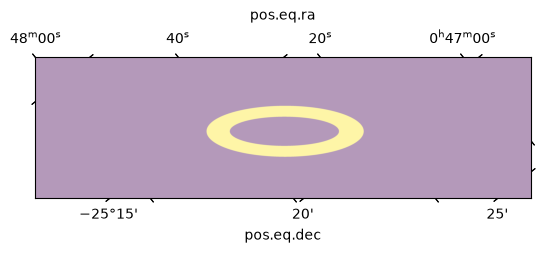

In [35]:
ha_ring_regionfile =  r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_ha_regionfile_muse_2.reg"
ring_region1 = Regions.read(ha_ring_regionfile)[0].to_pixel(wcs)
ring_region11 = Regions.read(ha_ring_regionfile)[1].to_pixel(wcs)


ring_mask1 = ring_region1.to_mask(mode='subpixels') #https://astropy-regions.readthedocs.io/en/stable/user_guide/masks.html#defining-a-region-mask-within-an-image
ring_mask11 = ring_region11.to_mask(mode='subpixels')
outer = ring_mask1.to_image(data.shape)
inner = ring_mask11.to_image(data.shape)

annulus_mask = (outer > 0) & (inner == 0)

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
ax.imshow(annulus_mask, cmap='viridis', origin='lower', alpha=0.4)
#ring_mask_array = np.where(ring_mask11.to_image(data.shape) == 1, 0, 0)
#ax.imshow(test_array, cmap='viridis', origin='lower', alpha=0.4)

plt.savefig('Mask: Ring, H-alpha Map')

## All Regions: Mask

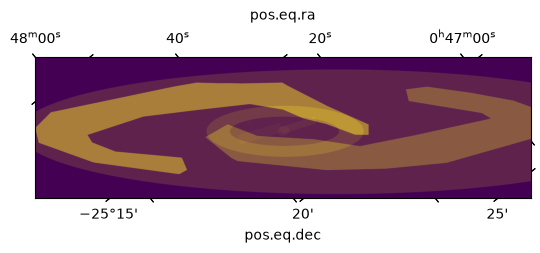

In [9]:
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
 #disk

ax.imshow(center_mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.9) #center
ax.imshow(bar_mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4) #bar
ax.imshow(bar_mask11.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4) #bar
ax.imshow(annulus_mask, cmap='viridis', origin='lower', alpha=0.5) #ring
ax.imshow(mask.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4)
ax.imshow(mask1.to_image(data.shape), cmap='viridis', origin='lower',alpha=0.4) #spiralarms
ax.imshow(mask11.to_image(data.shape), cmap='viridis', origin='lower',alpha=0.4)
#ax.imshow(ring_mask1.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4) #ring
#ax.imshow(ring_mask11.to_image(data.shape), cmap='viridis', origin='lower', alpha=0.4) #ring



In [13]:
mask_array = np.zeros(shape=np.shape(data), dtype=int)
disk_mask = np.copy(np.array(mask.to_image(data.shape)).astype(int))
#mask_array[disk_mask]
#print(np.shape(mask_array))
print(disk_mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


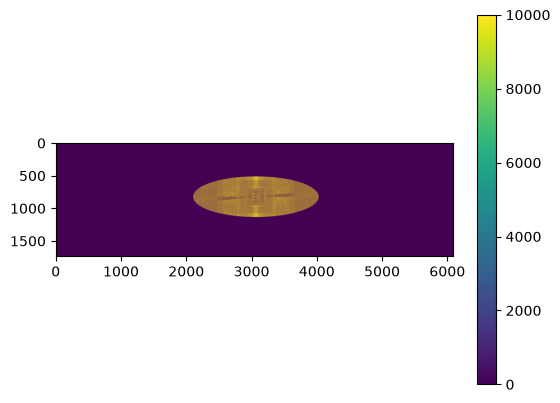

In [25]:
ring1mask = ring_mask1.to_image(data.shape)
ring1mask= ring1mask.astype(int)
ha_array = np.where(ring1mask == 1,10000, 0)
plt.imshow(ha_array)
plt.colorbar()
print(ring1mask)

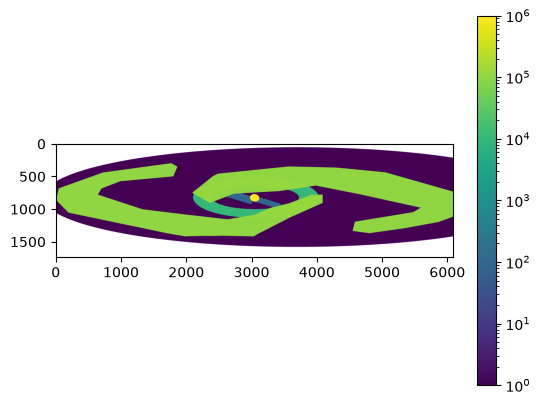

In [36]:
#mask_array = np.zeros(shape=np.shape(data), dtype=int)


mask_array = np.where((ring_mask1.to_image(data.shape)).astype(int) == 1,10000, 0)

mask_array = np.where((ring_mask11.to_image(data.shape)).astype(int) == 1, 0, mask_array)

mask_array = np.where((mask.to_image(data.shape)).astype(int) == 1, mask_array+1, 0) #disk, where the disk mask=1, assign pixel value 1 to the overall mask array

mask_array = np.where((mask1.to_image(data.shape)).astype(int) == 1, mask_array+100000, mask_array) #spiral arm 1

mask_array = np.where((mask11.to_image(data.shape)).astype(int) == 1, mask_array+100000, mask_array) # spiral arm 2

mask_array = np.where((center_mask1.to_image(data.shape)).astype(int) == 1, mask_array+1000000, mask_array)

mask_array = np.where((bar_mask1.to_image(data.shape)).astype(int) == 1, mask_array+100, mask_array)

mask_array = np.where((bar_mask11.to_image(data.shape)).astype(int) == 1, mask_array+100, mask_array)



plt.imshow(mask_array, norm='log')
plt.colorbar()
plt.show()


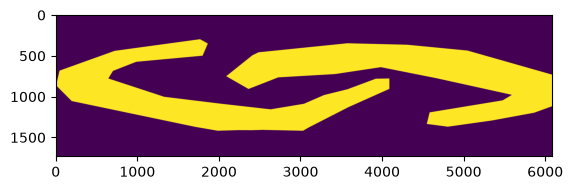

In [51]:
plt.imshow(mask_array)

In [52]:
np.where(mask.to_image(data.shape)==1)

(array([  57,   57,   58, ..., 1569, 1571, 1578], shape=(3325,)),
 array([3424, 4072, 3513, ..., 3830, 3847, 3824], shape=(3325,)))

In [37]:
hdu = fits.PrimaryHDU(data=mask_array)
print(hdu)
hdu.writeto('halpha_mask.fits', overwrite=True)

In [28]:
np.shape(mask)


(1529, 7793)